# MFAA Chapter 8 Laboratory
**Fund Cash-Flow Engine** (book §8.9)

Generate portfolio paths, push them through calls, fees, and a tier-tracked waterfall, and report the LP's world. The engine on which Chapters 9–10 mount asset-specific dynamics. Seed `20260800`.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0,'..')
from engine import ch08
from dataclasses import replace

## 1. The J-curve fan

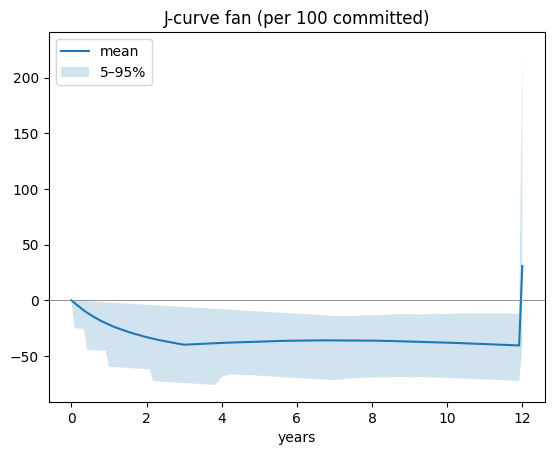

In [2]:
sim = ch08.simulate_fund(ch08.FundParams(M=8000))
net_cum = np.cumsum(sim['call_flow']+sim['dist_flow']+sim['fee_flow'], axis=0)
t = sim['tgrid']
plt.plot(t, net_cum.mean(axis=1), 'C0-', label='mean')
plt.fill_between(t, np.quantile(net_cum,.05,axis=1), np.quantile(net_cum,.95,axis=1), alpha=.2, label='5–95%')
plt.axhline(0, color='grey', lw=.6); plt.legend(); plt.title('J-curve fan (per 100 committed)'); plt.xlabel('years');

## 2. Ex 8.10 — tier-tracked European waterfall
Conservation W_LP + W_GP = G to the cent, on every path.

In [3]:
import numpy as np
called=np.array([100.,100.,100.,100.]); G=np.array([80.,108.,120.,200.])
wf = ch08.european_waterfall(G, called, ch08.FundParams(pref_rate=0.08), years=1.0)
for i in range(4): print(f'G={G[i]:.0f}: LP {wf["lp"][i]:.2f}, GP {wf["gp"][i]:.2f}, sum {wf["lp"][i]+wf["gp"][i]:.2f}')
print('max conservation error:', wf['conservation_error'])

G=80: LP 80.00, GP 0.00, sum 80.00
G=108: LP 108.00, GP 0.00, sum 108.00
G=120: LP 116.00, GP 4.00, sum 120.00
G=200: LP 180.00, GP 20.00, sum 200.00
max conservation error: 0.0


## 3. E3 — Manufacture an IRR with a subscription line
The subscription line shifts IRR right while PME stands still (Proposition 8.6(ii)).

In [4]:
import pandas as pd
pd.DataFrame(ch08.subscription_line_demo(ch08.FundParams(M=4000)))

,delay_quarters,pme_mean,tvpi_mean,irr_proxy
0,0,1.241557,1.970195,0.000
1,1,1.241557,1.970195,0.015
2,2,1.241557,1.970195,0.030
3,3,1.241557,1.970195,0.045
4,4,1.241557,1.970195,0.060


## 4. Performance measures & validation

In [5]:
pm = ch08.performance_measures(ch08.FundParams(M=8000))
print(f"TVPI {pm['tvpi_mean']:.3f}, DPI {pm['dpi_mean']:.3f}, PME {pm['pme_mean']:.3f}")
v = ch08.validation_checks()
for k,d in v.items():
    if isinstance(d,dict): print(k, 'PASS' if d['pass_'] else 'FAIL')
print('ALL:', v['all_pass'])

TVPI 1.960, DPI 1.960, PME 1.235
V1_conservation PASS
V2_waterfall_map PASS
V3_deterministic_limit PASS
V4_irr_roots PASS
V5_pme_stable PASS
V6_reproducible PASS
ALL: True
